# Business Understanding

# Business Problem
##### Google Careers has many job openings across different locations and experience levels. Since the job listings are spread across many pages, it is difficult to manually collect and analyze all the available jobs.
##### Therefore, the project focuses on collecting Google Careers job information and organizing it into a structured dataset for analysis.

# Business Objective
##### The objective of this project is to analyze Google job openings and understand:

##### Which locations have the most job opportunities.
##### Which experience levels have the most openings.
##### What types of jobs are available.
##### How job opportunities are distributed across different locations.

# Data Collection
##### The data was collected from the Google Careers website using Python web scraping.

##### The main tools used were:

##### Requests – to retrieve the web pages.
##### BeautifulSoup – to extract the required information.
##### Pandas – to store and work with the collected data.

In [1]:
import pandas as pd
import requests 
from bs4 import BeautifulSoup

In [2]:
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/138.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,/;q=0.8",
}

In [3]:
jobs=[]
experience_levels=["Early","Mid","Advanced","Director+","Intern & Apprentice"]
for i in range(1,168):
    url=f"https://www.google.com/about/careers/applications/jobs/results?_gl=1*zynud0*_ga*NDcxMDQ0NjYuMTc3MDI5OTY4Mg..*_ga_41NEC9ZD62*czE3ODU2OTcxNzckbzQkZzEkdDE3ODU2OTc1ODAkajYkbDAkaDA.&page={i}"
    # print(url)
    response=requests.get(url,headers=headers)
    print(f"Status code of page {i} :", response.status_code)
    # Get Html Data
    html_data=response.text
    # Parse the html data using BeautifulSoup
    soup=BeautifulSoup(html_data,"html.parser")
    # print(soup.text)
    # Get all job cards
    jobcards=soup.find_all("div",class_="sMn82b")
    for card in jobcards:
        # print(card.text)
        lines=card.get_text("\n",strip=True).split("\n")
        if "Minimum qualifications" in lines:
            lines=lines[:lines.index("Minimum qualifications")]
        lines=[line.strip() for line in lines if line.strip()]
        # job title
        if len(lines)>=7:
            job_title=lines[0]
            company=lines[2]
            location=lines[4]
            experience_level=next((line for line in lines if line in experience_levels),None)

            job={"job_title":job_title,
                 "company":company,
                 "location":location,
                 "experience_level":experience_level}
            jobs.append(job)
print("Total jobs scraped:",len(jobs))

Status code of page 1 : 200
Status code of page 2 : 200
Status code of page 3 : 200
Status code of page 4 : 200
Status code of page 5 : 200
Status code of page 6 : 200
Status code of page 7 : 200
Status code of page 8 : 200
Status code of page 9 : 200
Status code of page 10 : 200
Status code of page 11 : 200
Status code of page 12 : 200
Status code of page 13 : 200
Status code of page 14 : 200
Status code of page 15 : 200
Status code of page 16 : 200
Status code of page 17 : 200
Status code of page 18 : 200
Status code of page 19 : 200
Status code of page 20 : 200
Status code of page 21 : 200
Status code of page 22 : 200
Status code of page 23 : 200
Status code of page 24 : 200
Status code of page 25 : 200
Status code of page 26 : 200
Status code of page 27 : 200
Status code of page 28 : 200
Status code of page 29 : 200
Status code of page 30 : 200
Status code of page 31 : 200
Status code of page 32 : 200
Status code of page 33 : 200
Status code of page 34 : 200
Status code of page 35 

In [4]:
df=pd.DataFrame(jobs)
df

,job_title,company,location,experience_level
0,"Program Manager, Regulatory Program Management...",Google,"Mountain View, CA, USA",Mid
1,"Senior iOS UX Engineer, Search App",Google,"Mountain View, CA, USA",Mid
2,gUP Operations Program Manager,Google,"Dublin, Ireland",Mid
3,"Principal Strategist, Security, Strategic Cust...",Google,"New York, NY, USA",Advanced
4,"Senior Technical Program Manager, Pixel Device...",Google,"Mountain View, CA, USA",Advanced
...,...,...,...,...
3333,Principal Incident Response Security Consultan...,Google,"Georgia, USA",Advanced
3334,"Data Center Operations Technician, Night Shift",Google,"Haskell, TX, USA",Early
3335,"Data Center Facilities Technician, Controls",Google,"Reno, NV, USA",Early
3336,"Senior Software Engineer, Agent Platform Workb...",Google,"Warsaw, Poland",Mid


In [5]:
df.to_csv("Google_careers_webscrapping.csv",index=False)

In [5]:
df=pd.read_csv("Google_careers_webscrapping.csv")

In [10]:
df

,job_title,company,location,experience_level
0,"Program Manager, Regulatory Program Management...",Google,"Mountain View, CA, USA",Mid
1,"Senior iOS UX Engineer, Search App",Google,"Mountain View, CA, USA",Mid
2,gUP Operations Program Manager,Google,"Dublin, Ireland",Mid
3,"Principal Strategist, Security, Strategic Cust...",Google,"New York, NY, USA",Advanced
4,"Senior Technical Program Manager, Pixel Device...",Google,"Mountain View, CA, USA",Advanced
...,...,...,...,...
3333,Principal Incident Response Security Consultan...,Google,"Georgia, USA",Advanced
3334,"Data Center Operations Technician, Night Shift",Google,"Haskell, TX, USA",Early
3335,"Data Center Facilities Technician, Controls",Google,"Reno, NV, USA",Early
3336,"Senior Software Engineer, Agent Platform Workb...",Google,"Warsaw, Poland",Mid


# Data Undersatnding

In [3]:
import pandas as pd

### Shape Analysis

In [11]:
print("Number of Rows and Columns :",df.shape)

Number of Rows and Columns : (3338, 4)


##### There are 3338 rows and 4 columns in this dataset

### How many rows are available ?

In [12]:
print("Number of Rows :",df.shape[0])

Number of Rows : 3338


##### There are 3338 rows

### How many Columns are available?

In [13]:
print("Number of columns:",df.shape[1])

Number of columns: 4


##### There are 4 columns in trhis dataset

### What are the features available?

In [14]:
df.columns

Index(['job_title', 'company', 'location', 'experience_level'], dtype='object')

## Data Frame information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3338 entries, 0 to 3337
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         3338 non-null   object
 1   company           3338 non-null   object
 2   location          3338 non-null   object
 3   experience_level  3263 non-null   object
dtypes: object(4)
memory usage: 104.4+ KB


# Data Cleaning

### Finding Misiing Values

In [9]:
pd.DataFrame(df.isna().sum())

,0
job_title,0
company,0
location,0
experience_level,75


##### There are no missing values in tis dataset

### Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(13)

#### There are 13 duplicated rows

#### Removinf the duplicated rows

In [12]:
df=df.drop_duplicates().reset_index(drop=True)

In [13]:
df

,job_title,company,location,experience_level
0,"Program Manager, Regulatory Program Management...",Google,"Mountain View, CA, USA",Mid
1,"Senior iOS UX Engineer, Search App",Google,"Mountain View, CA, USA",Mid
2,gUP Operations Program Manager,Google,"Dublin, Ireland",Mid
3,"Principal Strategist, Security, Strategic Cust...",Google,"New York, NY, USA",Advanced
4,"Senior Technical Program Manager, Pixel Device...",Google,"Mountain View, CA, USA",Advanced
...,...,...,...,...
3320,Principal Incident Response Security Consultan...,Google,"Georgia, USA",Advanced
3321,"Data Center Operations Technician, Night Shift",Google,"Haskell, TX, USA",Early
3322,"Data Center Facilities Technician, Controls",Google,"Reno, NV, USA",Early
3323,"Senior Software Engineer, Agent Platform Workb...",Google,"Warsaw, Poland",Mid


#### Incorrect Datatypes


In [15]:
df.dtypes

job_title           object
company             object
location            object
experience_level    object
dtype: object

In [16]:
df.describe(include="object")

,job_title,company,location,experience_level
count,3325,3325,3325,3250
unique,3117,7,201,5
top,"Data Center Facilities Technician, Mechanical",Google,"Mountain View, CA, USA",Mid
freq,7,3122,413,1752


# Data Analysis

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Univariate Analysis

In [18]:
### Experience level

In [19]:
df.experience_level.value_counts()

experience_level
Mid                    1752
Advanced               1076
Early                   308
Intern & Apprentice      65
Director+                49
Name: count, dtype: int64

Text(0, 0.5, 'Counts')

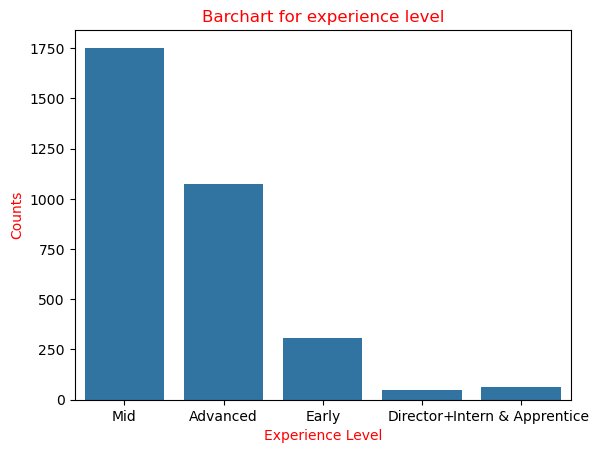

In [57]:
sns.countplot(data=df,x="experience_level")
plt.title("Barchart for experience level",color="red")
plt.xlabel("Experience Level",color="red")
plt.ylabel("Counts",color="red")


#### Observation :
##### The mid level is highest while compared with the advanced, early, director+,intern and apprentice

### Location

Text(0, 0.5, 'Counts')

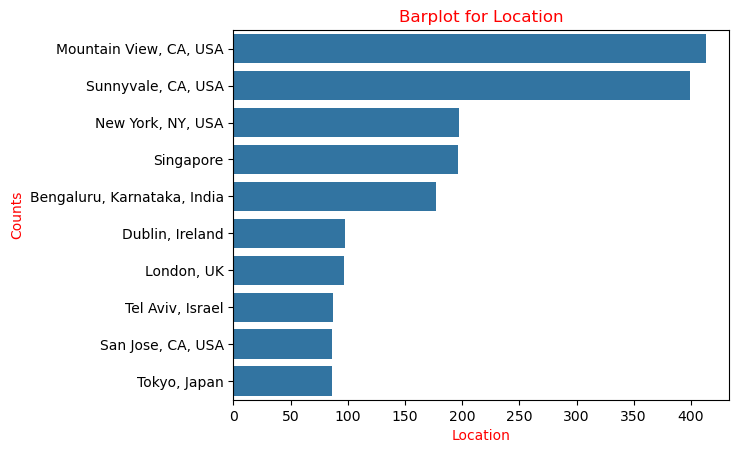

In [47]:
top_locations=df.location.value_counts().head(10)
sns.barplot(x=top_locations.values,y=top_locations.index)
plt.title("Barplot for Location",color="red")
plt.xlabel("Location",color="red")
plt.ylabel("Counts",color="red")



### Job title

In [41]:
df.job_title.mode()

0    Data Center Facilities Technician, Mechanical
1                           Data Center Technician
Name: job_title, dtype: object

In [45]:
df.job_title.value_counts().head(10)

job_title
Data Center Facilities Technician, Mechanical                   7
Data Center Technician                                          7
Community Development Manager, Strategic Partnerships Office    6
Data Center Facilities Technician, Electrical                   6
Data Center Facilities Technician, Controls                     5
Data Center Technician II                                       5
Data Center Mechanical Engineer                                 5
Community Development Manager, Strategic Partnership Office     5
AI Outcome Customer Engineer, Google Cloud                      5
Data Center Operations Manager                                  5
Name: count, dtype: int64

Text(0, 0.5, 'Counts')

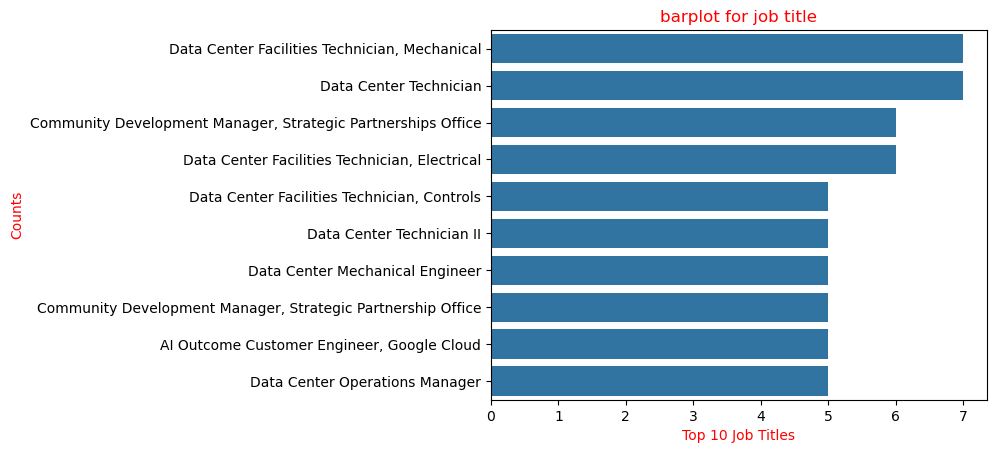

In [46]:
top_job_title=df.job_title.value_counts().head(10)
sns.barplot(x=top_job_title.values,y=top_job_title.index)
plt.title("barplot for job title",color="red")
plt.xlabel("Top 10 Job Titles",color="red")
plt.ylabel("Counts",color="red")



# Bivariate Analysis

### Experience vs location

Text(0, 0.5, 'Counts')

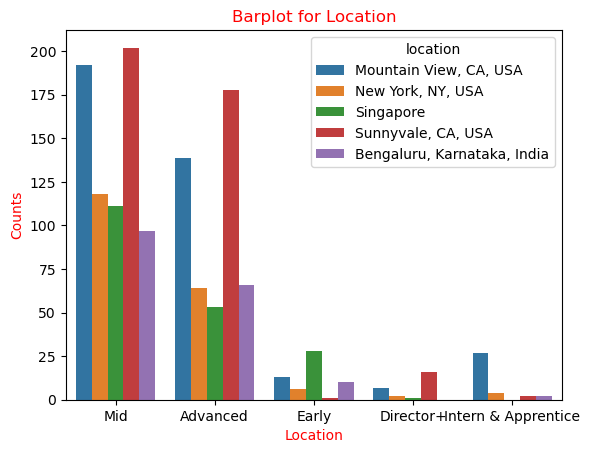

In [55]:
top_locations=df.location.value_counts().head(5)
df_top=df[df["location"].isin(top_locations.index)]
sns.countplot(data=df_top,hue="location",x="experience_level")
plt.title("Barplot for Location",color="red")
plt.xlabel("Location",color="red"
plt.ylabel("Counts",color="red")

### Experience vs Job title

<Axes: xlabel='experience_level', ylabel='count'>

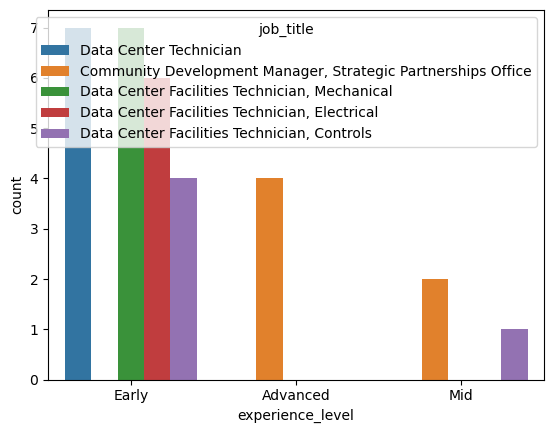

In [65]:
top_job_title=df.job_title.value_counts().head(5)
df_top_title=df[df["job_title"].isin(top_job_title.index)]
sns.countplot(data=df_top_title,x="experience_level",hue="job_title")

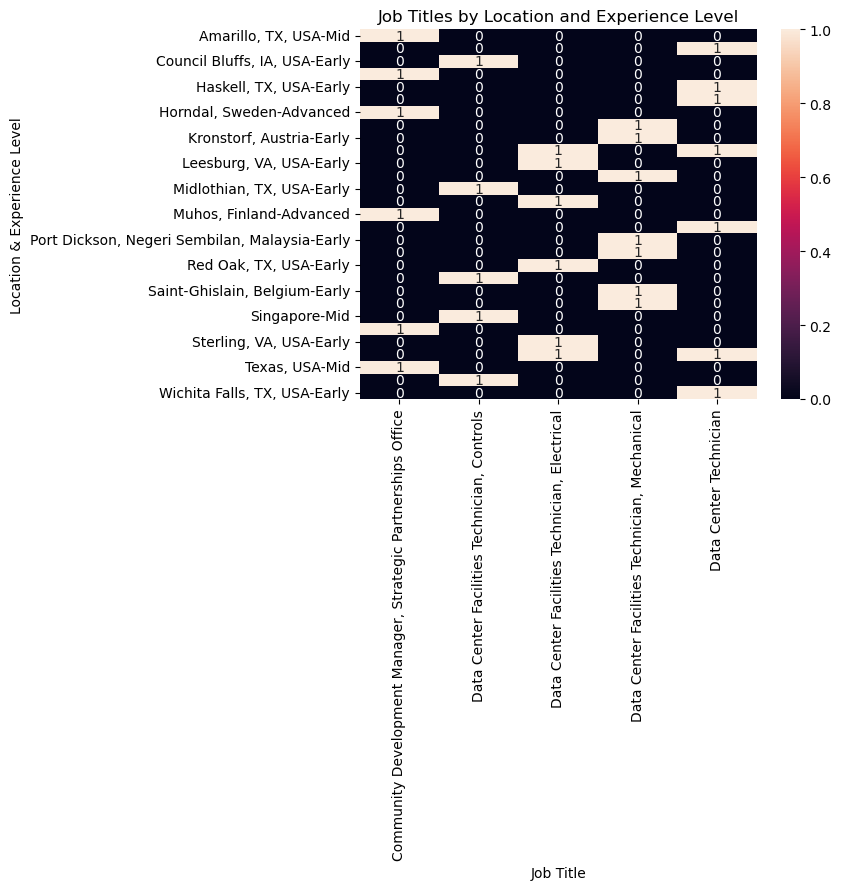

In [80]:
top_title = df["job_title"].value_counts().head(5).index

df_top = df[df["job_title"].isin(top_title)]

table = pd.crosstab(
    [df_top["location"], df_top["experience_level"]],
    df_top["job_title"]
)

sns.heatmap(table, annot=True, fmt="d")

plt.title("Job Titles by Location and Experience Level")
plt.xlabel("Job Title")
plt.ylabel("Location & Experience Level")
plt.show()

### Statistics 

#### Chi Square

In [74]:
from scipy.stats import chi2_contingency
table=pd.crosstab(df.location,df.job_title)
chi_stat,p_value,dof,expected_frequency=chi2_contingency(table)
print("Chi-square statistic:",chi_stat)
print("P-value:",p_value)
print("degree of freedom:",dof)
print("Expected Frequencies:",expected_frequency)
if p_value<0.05:
    print("Rejected H0")
else:
    print("Fail to Reject H0")
    

Chi-square statistic: 568150.4867934773
P-value: 1.0
degree of freedom: 623200
Expected Frequencies: [[0.00481203 0.00481203 0.00962406 ... 0.00481203 0.00481203 0.00481203]
 [0.00030075 0.00030075 0.0006015  ... 0.00030075 0.00030075 0.00030075]
 [0.00030075 0.00030075 0.0006015  ... 0.00030075 0.00030075 0.00030075]
 ...
 [0.00030075 0.00030075 0.0006015  ... 0.00030075 0.00030075 0.00030075]
 [0.00090226 0.00090226 0.00180451 ... 0.00090226 0.00090226 0.00090226]
 [0.01082707 0.01082707 0.02165414 ... 0.01082707 0.01082707 0.01082707]]
Fail to Reject H0


#### Observation:
##### The p value is greater than 0.05
#### Interpretation:
##### There is no significant association between Job title and location.


In [77]:
from scipy.stats import chi2_contingency
table=pd.crosstab(df.job_title,df.experience_level)
chi_stat,p_value,dof,expected_frequency=chi2_contingency(table)
print("Chi-square statistic:",chi_stat)
print("P-value:",p_value)
print("degree of freedom:",dof)
print("Expected Frequencies:",expected_frequency)
if p_value<0.05:
    print("Rejected H0")
else:
    print("Fail to Reject H0")
    

Chi-square statistic: 12874.428810512716
P-value: 4.879098148257675e-06
degree of freedom: 12172
Expected Frequencies: [[0.33107692 0.01507692 0.09476923 0.02       0.53907692]
 [0.33107692 0.01507692 0.09476923 0.02       0.53907692]
 [0.66215385 0.03015385 0.18953846 0.04       1.07815385]
 ...
 [0.33107692 0.01507692 0.09476923 0.02       0.53907692]
 [0.33107692 0.01507692 0.09476923 0.02       0.53907692]
 [0.33107692 0.01507692 0.09476923 0.02       0.53907692]]
Rejected H0


#### Observation :
##### The P value is less than 0.05

#### interpretation:
##### There is statistically significant association between job_title and experience_level 

In [78]:
from scipy.stats import chi2_contingency
table=pd.crosstab(df.location,df.experience_level)
chi_stat,p_value,dof,expected_frequency=chi2_contingency(table)
print("Chi-square statistic:",chi_stat)
print("P-value:",p_value)
print("degree of freedom:",dof)
print("Expected Frequencies:",expected_frequency)
if p_value<0.05:
    print("Rejected H0")
else:
    print("Fail to Reject H0")
    

Chi-square statistic: 1541.6176486585591
P-value: 3.203312373919854e-51
degree of freedom: 788
Expected Frequencies: [[5.29723077e+00 2.41230769e-01 1.51630769e+00 3.20000000e-01
  8.62523077e+00]
 [3.31076923e-01 1.50769231e-02 9.47692308e-02 2.00000000e-02
  5.39076923e-01]
 [3.31076923e-01 1.50769231e-02 9.47692308e-02 2.00000000e-02
  5.39076923e-01]
 [1.98646154e+00 9.04615385e-02 5.68615385e-01 1.20000000e-01
  3.23446154e+00]
 [1.32430769e+00 6.03076923e-02 3.79076923e-01 8.00000000e-02
  2.15630769e+00]
 [3.31076923e-01 1.50769231e-02 9.47692308e-02 2.00000000e-02
  5.39076923e-01]
 [9.93230769e-01 4.52307692e-02 2.84307692e-01 6.00000000e-02
  1.61723077e+00]
 [3.31076923e-01 1.50769231e-02 9.47692308e-02 2.00000000e-02
  5.39076923e-01]
 [1.48984615e+01 6.78461538e-01 4.26461538e+00 9.00000000e-01
  2.42584615e+01]
 [6.62153846e-01 3.01538462e-02 1.89538462e-01 4.00000000e-02
  1.07815385e+00]
 [1.45673846e+01 6.63384615e-01 4.16984615e+00 8.80000000e-01
  2.37193846e+01]
 [3

#### Observation :
##### The P value is less than 0.05

#### interpretation:
##### There is statistically significant association between location and experience_level 

In [79]:
df

,job_title,company,location,experience_level
0,"Program Manager, Regulatory Program Management...",Google,"Mountain View, CA, USA",Mid
1,"Senior iOS UX Engineer, Search App",Google,"Mountain View, CA, USA",Mid
2,gUP Operations Program Manager,Google,"Dublin, Ireland",Mid
3,"Principal Strategist, Security, Strategic Cust...",Google,"New York, NY, USA",Advanced
4,"Senior Technical Program Manager, Pixel Device...",Google,"Mountain View, CA, USA",Advanced
...,...,...,...,...
3320,Principal Incident Response Security Consultan...,Google,"Georgia, USA",Advanced
3321,"Data Center Operations Technician, Night Shift",Google,"Haskell, TX, USA",Early
3322,"Data Center Facilities Technician, Controls",Google,"Reno, NV, USA",Early
3323,"Senior Software Engineer, Agent Platform Workb...",Google,"Warsaw, Poland",Mid


## Insights and Observations

#### Mid level jobs have the highest number of postings.
#### Advance-level jobs are the second-highest category.
#### The dataset contains many different job locations.
#### The dataset contains a wide variety of job titles.
#### Data-center related roles are among the frequency occuring job titles.
#### Job title and experience level have a significant associaton.
#### Location and experience level have a significant asscoiation.
#### Location and job title do not show a significant association in the Chi-Square test